In [1]:
import os
os.chdir("D:/文章返修/source data/Figure_2/Panel_B")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
def classify_rna_data(input_rna, dis, freq, binsize, discard):
    data = input_rna.copy()
    distance = data['E'] - data['S']
    rna_long = data[distance >= dis]
    rna_long_hf = rna_long[rna_long['value'] > freq]
    
    mask_c = (rna_long_hf['S'] <= discard[0]) & (rna_long_hf['value']>discard[1])
    
    hist_data = []
    s = 0
    e = binsize
    lens = data['E'].max()
    while True:
        distance_hf = rna_long_hf[~mask_c]['E'] - rna_long_hf[~mask_c]['S']
        mask = (distance_hf >= s) & (distance_hf <= e)
        hist_data.append(rna_long_hf[~mask_c]['value'][mask].sum())
        s = e
        e += binsize
        if e >= lens:
            break
    
    return rna_long_hf[mask_c], rna_long_hf[~mask_c], hist_data

def return_proportion(file):
    recom_data = np.loadtxt(file, usecols=[0,1,2], dtype=[('S','<i4'),('E','<i4'),('value','<f8')])
    min_value = min(2000, recom_data['value'].max() / 100)
    rna_c, rna_nc, hist_data = classify_rna_data(recom_data, 100, 10, 100, [100, min_value])
    total_c = rna_c['value'].sum()
    total_nc = rna_nc['value'].sum()
    total = total_c + total_nc
    c_proportion = total_c / total
    nc_proportion = total_nc / total
    return c_proportion*100, nc_proportion*100

def plot_select_data(output_file,labels, *input_files):
    samples = len(input_files)
    proportion = np.zeros((2,samples))
    for i,sample in enumerate(input_files):
        tmp_c_proportion, tmp_nc_proportion = return_proportion(sample)
        print(tmp_c_proportion, tmp_nc_proportion)
        proportion[0,i] = tmp_c_proportion
        proportion[1,i] = tmp_nc_proportion

    fig, ax = plt.subplots(figsize=(6, 4))

    width = 0.6

    colors = ['#ee9242','#85288c']

    bottoms = [0] * proportion.shape[1]

    for i in range(proportion.shape[0]):
        for j in range(proportion.shape[1]):
            ax.bar(j, proportion[i,j], width, bottom=bottoms[j] ,
               color=colors[i], edgecolor='white', linewidth=1.5)
            ax.text(j, bottoms[j] + proportion[i,j]/2, f'{proportion[i,j]:.2f}%', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
            bottoms[j] += proportion[i,j]

    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
    ax.set_xticks(range(samples))
    ax.set_xticklabels(labels, fontsize=10)

    plt.tight_layout()
    plt.savefig(output_file)
    plt.show

91.6604983962497 8.339501603750309
93.72819013486749 6.271809865132509
95.35619601470967 4.6438039852903445
6.77846940000343 93.22153059999657
36.374891911013286 63.625108088986714
53.02166476624858 46.97833523375142


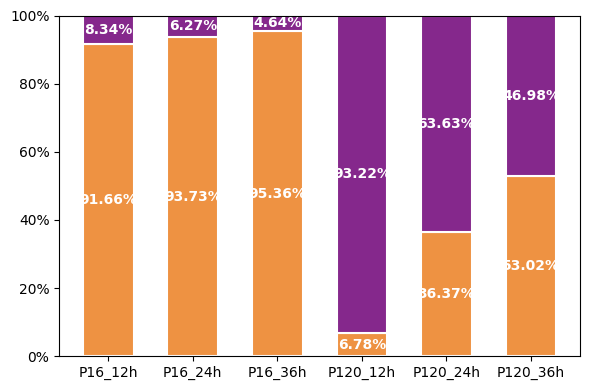

In [11]:
plot_select_data("1_alpha_PEDV_PRJNA801927-2Denteroids.pdf",
                 ['P16_12h','P16_24h','P16_36h',
                  'P120_12h','P120_24h','P120_36h'],
                 "1_alpha_PEDV_PRJNA801927-2Denteroids-12h-p16.1nt.none.matrix","1_alpha_PEDV_PRJNA801927-2Denteroids-24h-p16.1nt.none.matrix","1_alpha_PEDV_PRJNA801927-2Denteroids-36h-p16.1nt.none.matrix",
                 "1_alpha_PEDV_PRJNA801927-2Denteroids-12h-p120.1nt.none.matrix","1_alpha_PEDV_PRJNA801927-2Denteroids-24h-p120.1nt.none.matrix","1_alpha_PEDV_PRJNA801927-2Denteroids-36h-p120.1nt.none.matrix")